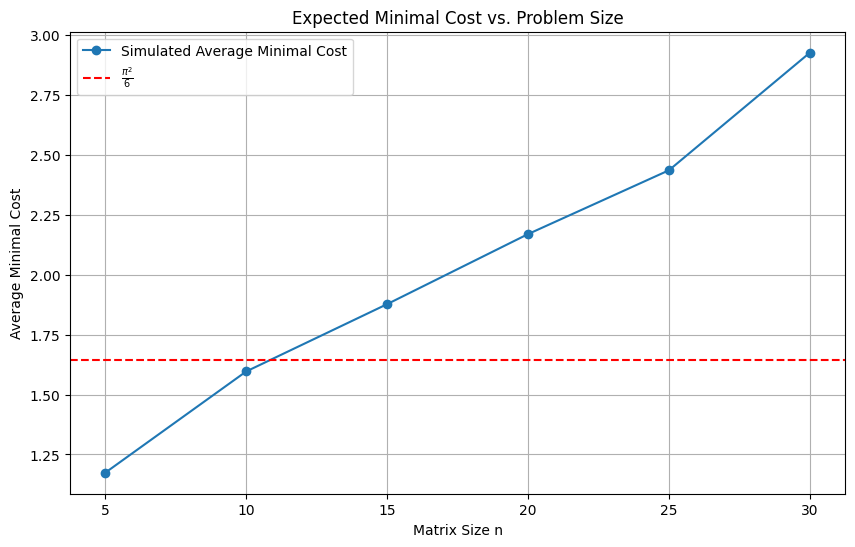

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

def generate_cost_matrix(n):
    """Generate an n x n cost matrix with entries drawn uniformly from [0, 1]."""
    return np.random.uniform(0, 1, (n, n))

def calculate_cost(C, sigma):
    """Calculate the total cost for a given permutation sigma using cost matrix C."""
    return np.sum(C[np.arange(len(sigma)), sigma])

def propose_new_permutation(sigma):
    """Generate a new permutation by swapping two random elements of the current permutation."""
    idx = np.random.choice(len(sigma), 2, replace=False)
    new_sigma = sigma.copy()
    new_sigma[idx[0]], new_sigma[idx[1]] = new_sigma[idx[1]], new_sigma[idx[0]]
    return new_sigma

def metropolis_hastings(C, beta, N, annealing_schedule):
    """Run the Metropolis-Hastings algorithm to find a minimizing permutation for the assignment cost."""
    n = len(C)
    sigma = np.random.permutation(n)
    current_cost = calculate_cost(C, sigma)
    costs = []

    for t in range(N):
        new_sigma = propose_new_permutation(sigma)
        new_cost = calculate_cost(C, new_sigma)
        # it check beta value between new cost and current cost
        if np.random.rand() < np.exp(-beta * (new_cost - current_cost)):
            sigma, current_cost = new_sigma, new_cost
            # updates the value of β
        beta = annealing_schedule(t, N, beta)
        # adds the current cost to a list called costs to keep track of the cost at each step
        costs.append(current_cost)

    return current_cost

def annealing_schedule_linear(t, N, beta):
    """Linear annealing schedule for beta."""
    return beta * (1 + t / N)

def run_simulation(n, beta, N, M, annealing_schedule):
    """Simulate the assignment problem for a given size and calculate average minimal cost."""
    costs = Parallel(n_jobs=-1)(delayed(metropolis_hastings)(generate_cost_matrix(n), beta, N, annealing_schedule) for _ in range(M))
    return np.mean(costs)

# Parameters
beta_initial = 1.0  # Initial control parameter
M = 100     # Number of simulations per size
n_values = [5, 10, 15, 20, 25, 30]  # Range of n values
N = 1000    # Steps in Metropolis-Hastings algorithm

# Run the simulation
avg_costs = [run_simulation(n, beta_initial, N, M, annealing_schedule_linear) for n in n_values]

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(n_values, avg_costs, marker='o', linestyle='-', label='Simulated Average Minimal Cost')
plt.axhline(y=np.pi**2 / 6, color='r', linestyle='--', label=r'$\frac{\pi^2}{6}$')
plt.xlabel('Matrix Size n')
plt.ylabel('Average Minimal Cost')
plt.title('Expected Minimal Cost vs. Problem Size')
plt.legend()
plt.grid(True)
plt.show()